# ATIVIDADE PRÁTICA – ANÁLISE DE ALGORITMOS DE ORDENAÇÃO

## Central de Distribuição de Pedidos

**Objetivo:** desenvolver, em Python, um experimento para comparar a quantidade de operações realizadas pelos algoritmos Bubble Sort, Insertion Sort, Selection Sort e Quick Sort.

Os experimentos serão realizados com vetores de **10, 20 e 1.000 elementos**, usando os mesmos dados iniciais para os quatro algoritmos em cada tamanho.

> **Reprodutibilidade:** foi utilizada a semente `SEED = 42`, para que os resultados possam ser reproduzidos no Google Colab.


## Critério de contagem

- **Comparações:** cada operação que compara dois valores do vetor durante a ordenação.
- **Bubble Sort:** movimentação = cada troca entre dois elementos.
- **Insertion Sort:** movimentação = cada deslocamento de elemento + a colocação da chave quando ela muda de posição.
- **Selection Sort:** movimentação = cada troca realizada.
- **Quick Sort:** movimentação = cada troca realizada durante a partição.

Em cada experimento, todos os algoritmos recebem uma **cópia idêntica** do mesmo vetor original.


## 1. Importação e configuração

In [1]:
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Necessário para o Quick Sort no pior caso com 1.000 elementos.
sys.setrecursionlimit(10000)

SEED = 42
TAMANHOS = [10, 20, 1000]


## 2. Bubble Sort

In [2]:
def bubble_sort(arr):
    vetor = arr.copy()
    comparacoes = 0
    trocas = 0
    n = len(vetor)

    for i in range(n - 1):
        houve_troca = False

        for j in range(n - 1 - i):
            comparacoes += 1

            if vetor[j] > vetor[j + 1]:
                vetor[j], vetor[j + 1] = vetor[j + 1], vetor[j]
                trocas += 1
                houve_troca = True

        # Otimização: se não houve troca, o vetor já está ordenado.
        if not houve_troca:
            break

    return vetor, comparacoes, trocas


## 3. Insertion Sort

In [3]:
def insertion_sort(arr):
    vetor = arr.copy()
    comparacoes = 0
    movimentacoes = 0

    for i in range(1, len(vetor)):
        chave = vetor[i]
        j = i - 1

        while j >= 0:
            comparacoes += 1

            if vetor[j] > chave:
                vetor[j + 1] = vetor[j]
                movimentacoes += 1
                j -= 1
            else:
                break

        # Conta a colocação da chave quando ela muda de posição.
        if j + 1 != i:
            vetor[j + 1] = chave
            movimentacoes += 1

    return vetor, comparacoes, movimentacoes


## 4. Selection Sort

In [4]:
def selection_sort(arr):
    vetor = arr.copy()
    comparacoes = 0
    trocas = 0
    n = len(vetor)

    for i in range(n - 1):
        indice_menor = i

        for j in range(i + 1, n):
            comparacoes += 1

            if vetor[j] < vetor[indice_menor]:
                indice_menor = j

        if indice_menor != i:
            vetor[i], vetor[indice_menor] = vetor[indice_menor], vetor[i]
            trocas += 1

    return vetor, comparacoes, trocas


## 5. Quick Sort

In [5]:
def quick_sort(arr):
    vetor = arr.copy()
    comparacoes = 0
    movimentacoes = 0

    def particionar(inicio, fim):
        nonlocal comparacoes, movimentacoes

        # Pivô: último elemento da partição.
        pivo = vetor[fim]
        i = inicio - 1

        for j in range(inicio, fim):
            comparacoes += 1

            if vetor[j] <= pivo:
                i += 1

                if i != j:
                    vetor[i], vetor[j] = vetor[j], vetor[i]
                    movimentacoes += 1

        if i + 1 != fim:
            vetor[i + 1], vetor[fim] = vetor[fim], vetor[i + 1]
            movimentacoes += 1

        return i + 1

    def ordenar(inicio, fim):
        if inicio < fim:
            p = particionar(inicio, fim)
            ordenar(inicio, p - 1)
            ordenar(p + 1, fim)

    ordenar(0, len(vetor) - 1)

    return vetor, comparacoes, movimentacoes


## 6. Geração dos dados

In [6]:
# Gera UM vetor aleatório para cada tamanho.
# Depois, cada algoritmo trabalha em uma cópia desse mesmo vetor.

rng = random.Random(SEED)
vetores_originais = {}

for tamanho in TAMANHOS:
    vetores_originais[tamanho] = [
        rng.randint(1, 10000) for _ in range(tamanho)
    ]

print("Vetores gerados:")
for tamanho, vetor in vetores_originais.items():
    if tamanho <= 20:
        print(f"{tamanho} elementos:", vetor)
    else:
        print(f"{tamanho} elementos: vetor com {len(vetor)} valores aleatórios.")


Vetores gerados:
10 elementos: [1825, 410, 4507, 4013, 3658, 2287, 1680, 8936, 1425, 9675]
20 elementos: [6913, 521, 489, 1536, 3583, 3812, 8280, 9864, 435, 9196, 3258, 8929, 6874, 3612, 7360, 9655, 4558, 107, 2616, 6925]
1000 elementos: vetor com 1000 valores aleatórios.


## 7. Execução dos quatro algoritmos

In [7]:
algoritmos = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Selection Sort": selection_sort,
    "Quick Sort": quick_sort
}

resultados = []

for tamanho in TAMANHOS:
    original = vetores_originais[tamanho]

    for nome, funcao in algoritmos.items():
        vetor_algoritmo = original.copy()

        vetor_ordenado, comparacoes, movimentacoes = funcao(vetor_algoritmo)

        # Confirma que o algoritmo realmente ordenou o vetor.
        assert vetor_ordenado == sorted(original)

        resultados.append({
            "Tamanho": tamanho,
            "Algoritmo": nome,
            "Comparações": comparacoes,
            "Trocas/Movimentações": movimentacoes
        })

df_resultados = pd.DataFrame(resultados)
df_resultados


,Tamanho,Algoritmo,Comparações,Trocas/Movimentações
0,10,Bubble Sort,44,19
1,10,Insertion Sort,27,25
2,10,Selection Sort,45,7
3,10,Quick Sort,29,7
4,20,Bubble Sort,189,84
5,20,Insertion Sort,99,101
6,20,Selection Sort,190,16
7,20,Quick Sort,58,28
8,1000,Bubble Sort,499122,239681
9,1000,Insertion Sort,240670,240676


## 8. Tabela de resultados

In [8]:
tabela_final = pd.DataFrame(index=TAMANHOS)

for nome in algoritmos:
    dados = df_resultados[df_resultados["Algoritmo"] == nome].set_index("Tamanho")
    tabela_final[f"{nome} - Comparações"] = dados["Comparações"]
    tabela_final[f"{nome} - Trocas/Mov."] = dados["Trocas/Movimentações"]

tabela_final


,Bubble Sort - Comparações,Bubble Sort - Trocas/Mov.,Insertion Sort - Comparações,Insertion Sort - Trocas/Mov.,Selection Sort - Comparações,Selection Sort - Trocas/Mov.,Quick Sort - Comparações,Quick Sort - Trocas/Mov.
10,44,19,27,25,45,7,29,7
20,189,84,99,101,190,16,58,28
1000,499122,239681,240670,240676,499500,992,10385,4543


### Resultado obtido

Com `SEED = 42`, a execução produziu:

| Tamanho | Bubble Comp. | Bubble Trocas | Insertion Comp. | Insertion Mov. | Selection Comp. | Selection Trocas | Quick Comp. | Quick Mov. |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 10 | 44 | 19 | 27 | 25 | 45 | 7 | 29 | 7 |
| 20 | 189 | 84 | 99 | 101 | 190 | 16 | 58 | 28 |
| 1.000 | 499.122 | 239.681 | 240.670 | 240.676 | 499.500 | 992 | 10.385 | 4.543 |


## 9. Gráfico – Comparações

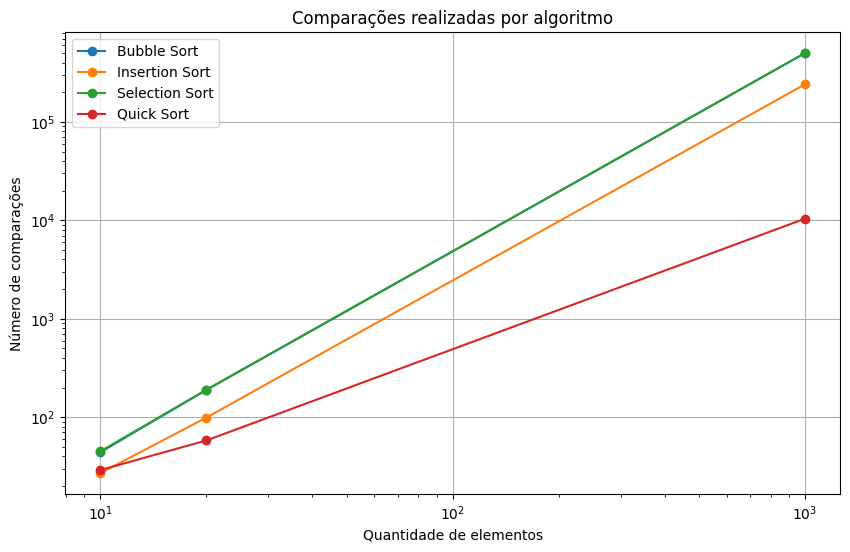

In [9]:
plt.figure(figsize=(10, 6))

for nome in algoritmos:
    dados = df_resultados[df_resultados["Algoritmo"] == nome]
    plt.plot(dados["Tamanho"], dados["Comparações"], marker="o", label=nome)

plt.title("Comparações realizadas por algoritmo")
plt.xlabel("Quantidade de elementos")
plt.ylabel("Número de comparações")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()


## 10. Gráfico – Trocas e movimentações

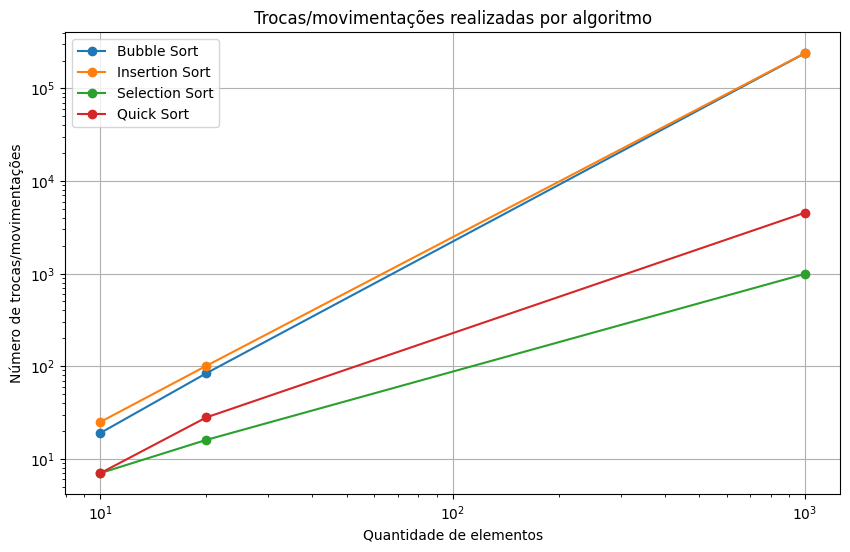

In [10]:
plt.figure(figsize=(10, 6))

for nome in algoritmos:
    dados = df_resultados[df_resultados["Algoritmo"] == nome]
    plt.plot(dados["Tamanho"], dados["Trocas/Movimentações"], marker="o", label=nome)

plt.title("Trocas/movimentações realizadas por algoritmo")
plt.xlabel("Quantidade de elementos")
plt.ylabel("Número de trocas/movimentações")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()


# Etapa 4 – Análise dos resultados

### a) Qual algoritmo realizou o menor número de comparações para 10 elementos?

O **Insertion Sort**, com **27 comparações**.

### b) Qual algoritmo realizou o menor número de trocas ou movimentações?

O **Selection Sort** e o **Quick Sort** empataram neste experimento, com **7 movimentações** cada.

### c) O comportamento observado para 10 elementos permaneceu semelhante quando o tamanho aumentou para 20?

Não exatamente. O crescimento ficou mais evidente. Bubble Sort e Selection Sort continuaram com muitas comparações, enquanto o Quick Sort apresentou crescimento bem menor. O Insertion Sort também cresceu, dependendo da organização dos dados.

### d) O que aconteceu com a quantidade de operações quando o vetor passou para 1.000 elementos?

A quantidade de operações aumentou muito. Bubble Sort e Selection Sort chegaram a aproximadamente **500 mil comparações**. O Insertion Sort passou de **240 mil comparações**, enquanto o Quick Sort ficou em apenas **10.385 comparações** nesse vetor aleatório.

### e) Bubble Sort, Insertion Sort e Selection Sort têm O(n²) em situações típicas. Eles fizeram exatamente a mesma quantidade de operações?

**Não.** A mesma complexidade assintótica não significa a mesma quantidade de operações. Com 1.000 elementos, por exemplo, Bubble Sort fez 499.122 comparações, Insertion Sort fez 240.670 e Selection Sort fez 499.500.

### f) Qual algoritmo apresentou maior crescimento no número de operações?

**Bubble Sort e Selection Sort** apresentaram o maior crescimento nas comparações, chegando próximo de meio milhão para 1.000 elementos.

### g) Como o Quick Sort se diferenciou dos demais?

No vetor aleatório de 1.000 elementos, o Quick Sort fez **10.385 comparações**, muito abaixo das aproximadamente 500 mil do Bubble Sort e Selection Sort. Isso está relacionado ao seu comportamento médio próximo de **O(n log n)**.

### h) Os resultados são coerentes com as complexidades teóricas?

**Sim.** Bubble Sort, Insertion Sort e Selection Sort podem apresentar comportamento **O(n²)** em situações típicas. O Quick Sort possui comportamento médio **O(n log n)**, mas pode chegar a **O(n²)** no pior caso.

### i) Qual algoritmo escolheria para milhares de pedidos?

Eu escolheria o **Quick Sort**, com uma implementação que utilize uma boa estratégia de escolha do pivô. No experimento com 1.000 valores aleatórios, ele teve o menor número de comparações entre os quatro algoritmos, mostrando melhor escalabilidade para grandes volumes de dados.


# Desafio adicional – influência da organização inicial

Foi utilizado o mesmo conjunto de **1.000 valores**, mudando apenas a ordem inicial:

1. vetor aleatório;
2. vetor já ordenado;
3. vetor em ordem inversa.

Dessa forma, a comparação fica mais justa.


In [11]:
vetor_aleatorio = vetores_originais[1000]
vetor_ordenado = sorted(vetor_aleatorio)
vetor_inverso = sorted(vetor_aleatorio, reverse=True)

vetores_desafio = {
    "Aleatório": vetor_aleatorio,
    "Ordenado": vetor_ordenado,
    "Ordem inversa": vetor_inverso
}

resultados_desafio = []

for organizacao, vetor in vetores_desafio.items():
    for nome, funcao in algoritmos.items():
        vetor_resultado, comparacoes, movimentacoes = funcao(vetor.copy())

        assert vetor_resultado == sorted(vetor)

        resultados_desafio.append({
            "Organização inicial": organizacao,
            "Algoritmo": nome,
            "Comparações": comparacoes,
            "Trocas/Movimentações": movimentacoes
        })

df_desafio = pd.DataFrame(resultados_desafio)
df_desafio


,Organização inicial,Algoritmo,Comparações,Trocas/Movimentações
0,Aleatório,Bubble Sort,499122,239681
1,Aleatório,Insertion Sort,240670,240676
2,Aleatório,Selection Sort,499500,992
3,Aleatório,Quick Sort,10385,4543
4,Ordenado,Bubble Sort,999,0
5,Ordenado,Insertion Sort,999,0
6,Ordenado,Selection Sort,499500,0
7,Ordenado,Quick Sort,499500,0
8,Ordem inversa,Bubble Sort,499500,499456
9,Ordem inversa,Insertion Sort,499496,500455


## Resultado do desafio adicional – 1.000 elementos

| Organização | Algoritmo | Comparações | Trocas/Movimentações |
|---|---|---:|---:|
| Aleatório | Bubble Sort | 499.122 | 239.681 |
| Aleatório | Insertion Sort | 240.670 | 240.676 |
| Aleatório | Selection Sort | 499.500 | 992 |
| Aleatório | Quick Sort | 10.385 | 4.543 |
| Ordenado | Bubble Sort | 999 | 0 |
| Ordenado | Insertion Sort | 999 | 0 |
| Ordenado | Selection Sort | 499.500 | 0 |
| Ordenado | Quick Sort | 499.500 | 0 |
| Ordem inversa | Bubble Sort | 499.500 | 499.456 |
| Ordem inversa | Insertion Sort | 499.496 | 500.455 |
| Ordem inversa | Selection Sort | 499.500 | 517 |
| Ordem inversa | Quick Sort | 483.534 | 517 |

### Análise do desafio

A organização inicial **interfere na quantidade de operações**.

- **Bubble Sort:** teve ótimo resultado no vetor ordenado porque o algoritmo identifica que não houve troca e encerra. Na ordem inversa, realizou muitas trocas.
- **Insertion Sort:** também se beneficia muito do vetor ordenado, pois praticamente não precisa movimentar elementos. Na ordem inversa, realizou muitas movimentações.
- **Selection Sort:** realizou praticamente a mesma quantidade de comparações nos três casos, porque continua procurando o menor elemento em cada posição. A quantidade de trocas varia.
- **Quick Sort:** apresentou excelente resultado no vetor aleatório, mas teve desempenho ruim no vetor ordenado e no vetor inverso. Como o pivô foi sempre o último elemento, as partições ficaram muito desequilibradas, levando ao pior caso **O(n²)**.

**Conclusão do desafio:** a organização inicial dos dados pode alterar bastante o desempenho dos algoritmos.


# Conclusão geral

O experimento mostrou que a complexidade teórica não determina uma quantidade exata de operações. Algoritmos com a mesma complexidade podem apresentar números de comparações e movimentações bastante diferentes.

Para 1.000 elementos aleatórios, o **Quick Sort** apresentou o melhor resultado em comparações. Já Bubble Sort e Selection Sort ficaram próximos de 500 mil comparações.

O desafio adicional mostrou que a **ordem inicial dos dados também influencia o desempenho**, principalmente no Bubble Sort, Insertion Sort e Quick Sort.

Portanto, para uma central de distribuição que precisa ordenar milhares de pedidos, o **Quick Sort** seria a escolha entre os quatro algoritmos estudados, desde que seja implementado com uma estratégia adequada para escolha do pivô.
